# aule — Core metrics

This notebook demonstrates the **core distribution metrics** in `aule.metrics.core`: classic error metrics (RMSE, MAE, MSE, bias) plus image-quality and goodness-of-fit metrics (SSIM, PSNR, R², MAPE, SMAPE, NSE, KGE, max error, explained variance).

All metrics accept numpy arrays in 4 possible shapes: `(H, W, C)`, `(H, W, C, T)`, `(batch, H, W, C)`, `(batch, H, W, C, T)`. We'll mostly use `(H, W, C)` here for simplicity.

In [ ]:
!pip install aule

## Setup

We simulate a simple ground truth field and a noisy prediction of it, as if it were a single-band satellite image (e.g. a temperature or reflectance map).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

gt   = np.random.rand(64, 64, 1)
pred = gt + np.random.normal(0, 0.1, gt.shape)  # add some Gaussian noise to simulate model error

print('gt shape:  ', gt.shape)
print('pred shape:', pred.shape)

gt shape:   (64, 64, 1)
pred shape: (64, 64, 1)


## Basic error metrics

RMSE, MAE, MSE and bias are the most common pixel-wise error metrics. RMSE/MSE penalize large errors more than MAE; bias tells us if the model systematically over- or under-predicts.

In [3]:
from aule.metrics import rmse, mae, mse, bias

print('RMSE:', rmse(gt, pred))
print('MAE: ', mae(gt, pred))
print('MSE: ', mse(gt, pred))   # should equal RMSE**2
print('Bias:', bias(gt, pred))  # close to 0 since noise is zero-mean

RMSE: 0.10168291204078489
MAE:  0.08092722605482462
MSE:  0.010339414601093996
Bias: -0.002943814370990332


## Correlation and goodness-of-fit

`pearson_r` measures linear correlation. `r2_score` (and the equivalent `nse`, common in hydrology/climate literature) measure how much better the model is than simply predicting the mean.

In [4]:
from aule.metrics import pearson_r, r2_score, nse

print('Pearson r:', pearson_r(gt, pred))
print('R2 score: ', r2_score(gt, pred))
print('NSE:      ', nse(gt, pred))  # identical formula to r2_score, different name convention

Pearson r: 0.9441261946461642
R2 score:  0.8772203896525492
NSE:       0.8772203896525492


## Percentage errors

`mape` divides by the ground truth value, so it can blow up when `y_true` is close to zero. `smape` is the symmetric, bounded alternative — generally safer for data that can be near zero.

In [5]:
from aule.metrics import mape, smape

# shift the data away from zero so MAPE is well-behaved for this demo
gt_shifted = gt + 1.0
pred_shifted = pred + 1.0

print('MAPE (%): ', mape(gt_shifted, pred_shifted))
print('SMAPE (%):', smape(gt_shifted, pred_shifted))

MAPE (%):  5.615626620254936
SMAPE (%): 5.645562490429959


## Kling-Gupta Efficiency (KGE)

KGE decomposes the error into three interpretable components: correlation (`r`), variability ratio (`alpha`, std_pred/std_true) and bias ratio (`beta`, mean_pred/mean_true). This is very popular in climate/hydrology model validation because it tells you *why* a model is wrong, not just by how much.

In [6]:
from aule.metrics import kge

result = kge(gt, pred)
print('KGE:  ', result['kge'])
print('r:    ', result['r'])
print('alpha:', result['alpha'])
print('beta: ', result['beta'])

KGE:   0.9158365654798619
r:     0.9441261946461642
alpha: 1.0626629960602951
beta:  0.9940881043433871


## Max error and explained variance

`max_error` gives a worst-case bound (useful for safety-critical applications); `explained_variance` is similar to R² but ignores constant bias.

In [7]:
from aule.metrics import max_error, explained_variance

print('Max error:         ', max_error(gt, pred))
print('Explained variance:', explained_variance(gt, pred))

Max error:          0.35290551875704845
Explained variance: 0.8773232981275537


## Image-quality metrics: SSIM and PSNR

SSIM compares local structure (not just pixel values) and is more perceptually meaningful for image-like data. PSNR is a classic image-quality metric in dB — higher is better, and it goes to infinity for a perfect reconstruction.

In [8]:
from aule.metrics import ssim, psnr

print('SSIM:', ssim(gt, pred))
print('PSNR (dB):', psnr(gt, pred, data_range=1.0))
print('PSNR identical (should be inf):', psnr(gt, gt))

SSIM: 0.9403868531591049
PSNR (dB): 19.855040495120598
PSNR identical (should be inf): inf


## Handling missing data

Every metric accepts an `ignore_nan=True` flag to exclude non-finite values from the computation, useful for masked satellite scenes (e.g. cloud cover) or missing observations.

In [9]:
gt_with_gaps = gt.copy()
gt_with_gaps[:5, :5] = np.nan  # simulate a cloud-covered corner

print('RMSE ignoring NaNs:', rmse(gt_with_gaps, pred, ignore_nan=True))
# without ignore_nan, NaNs propagate and the result is NaN:
print('RMSE without ignore_nan:', rmse(gt_with_gaps, pred, ignore_nan=False))

RMSE ignoring NaNs: 0.10158514691422936
RMSE without ignore_nan: nan


## Distributional metrics: Wasserstein distance and quantile mapping bias

All the metrics above compare values pixel by pixel (or pointwise). Sometimes what matters is whether the overall *distribution* of values matches, even if individual pixels don't align — for example when checking if a model reproduces the right range and frequency of extreme values, regardless of exactly where they occur.

`wasserstein_distance` (Earth Mover's Distance) measures how much "work" it takes to reshape one distribution into the other; it's especially informative for heavy-tailed data like precipitation. `quantile_mapping_bias` is the diagnostic typically computed before applying quantile-mapping bias correction to climate model output: it shows the mean absolute bias across the full quantile range, not just the mean.

In [10]:
from aule.metrics import wasserstein_distance, quantile_mapping_bias

# heavy-tailed example, e.g. precipitation-like data
precip_gt   = np.random.exponential(1.0, (8, 64, 64, 1))
precip_pred = precip_gt * 1.2  # systematically overestimates magnitude

print('Wasserstein distance:', wasserstein_distance(precip_gt, precip_pred))
print('Quantile mapping bias:', quantile_mapping_bias(precip_gt, precip_pred))

Wasserstein distance: 0.20066246527524703
Quantile mapping bias: 0.21118293344689668


## A quick visual sanity check

We didn't use `aule.plots` yet (see the other notebooks for that), but a quick matplotlib scatter is a good gut-check that our simulated prediction makes sense.

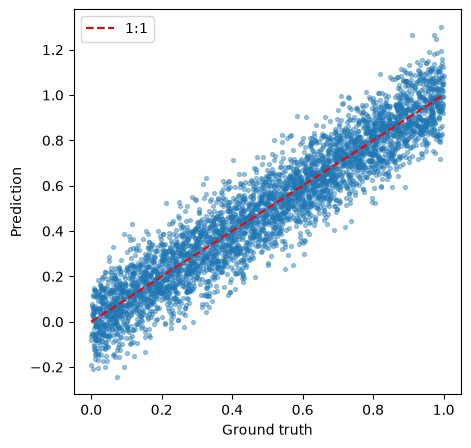

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(gt.ravel(), pred.ravel(), s=8, alpha=0.4)
lims = [gt.min(), gt.max()]
ax.plot(lims, lims, 'r--', label='1:1')
ax.set_xlabel('Ground truth')
ax.set_ylabel('Prediction')
ax.legend()
plt.show()